Importing dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
from scipy.stats import mstats

Setting styple and display options

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

Combinning the cleaned datasets into one data frame

In [4]:
countries = ['ethiopia', 'kenya', 'nigeria', 'tanzania', 'sudan']
dataframes = {}
loaded_countries = []

for country in countries:
    try:
        df = pd.read_csv(f'data/{country}_clean.csv')
        df['Country'] = country.capitalize()
        df['Date'] = pd.to_datetime(df['Date'])
        dataframes[country] = df
        loaded_countries.append(country.capitalize())
    except FileNotFoundError:
        print(f"✗ Warning: {country}_clean.csv not found - using available data")

if dataframes:
    combined_df = pd.concat(dataframes.values(), ignore_index=True)
    print(f"Countries included: {', '.join(combined_df['Country'].unique())}")
else:
    print("❌ No data files found. Please ensure cleaned CSV files are in data/ directory.")

Countries included: Ethiopia, Kenya, Nigeria, Tanzania, Sudan


monthly avarage T2m

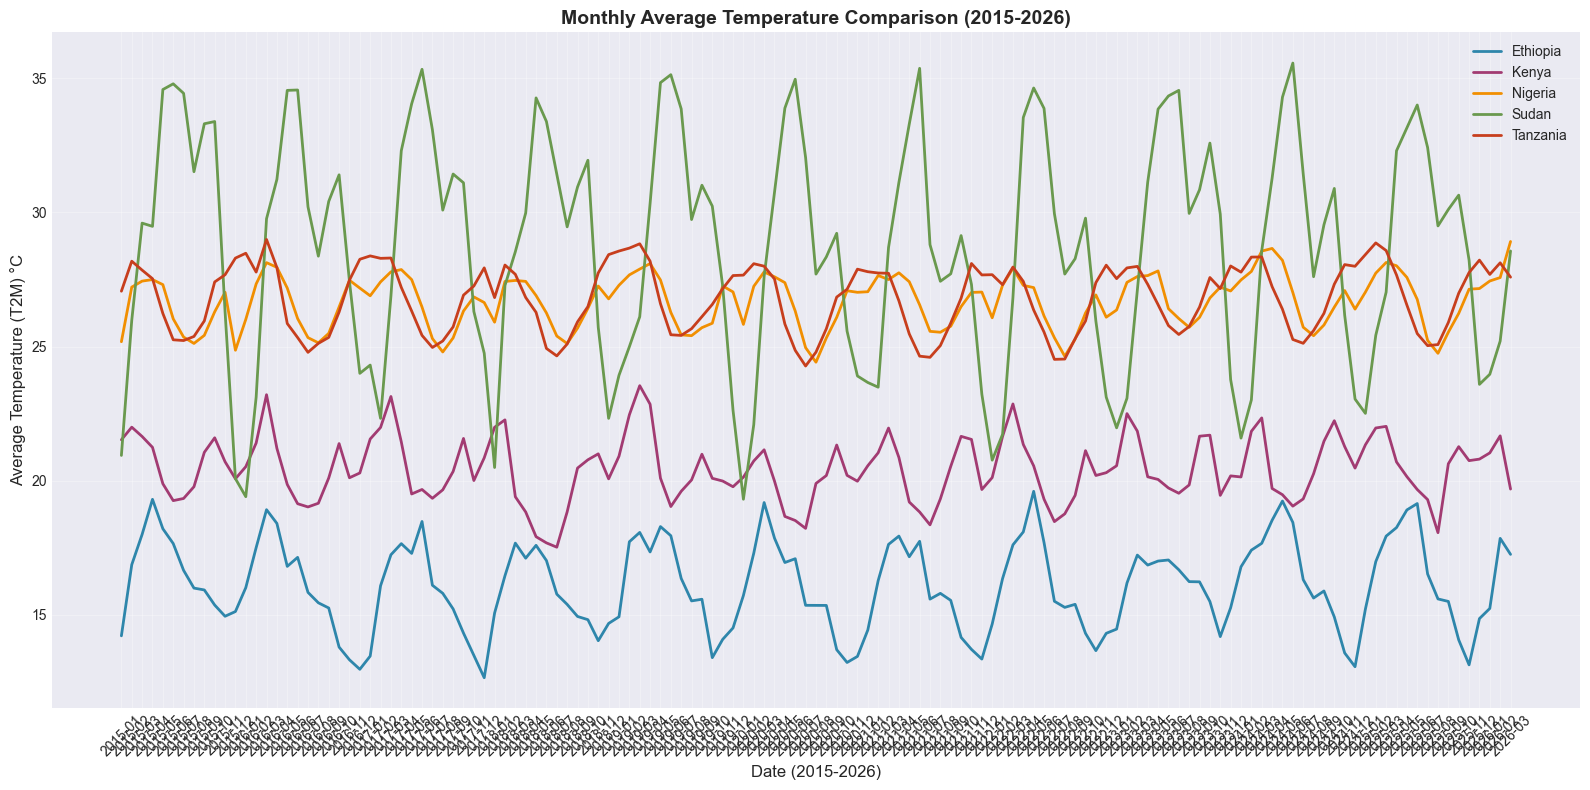

In [5]:
combined_df['YearMonth'] = combined_df['Date'].dt.to_period('M')
monthly_avg = combined_df.groupby(['Country', 'YearMonth'])['T2M'].mean().reset_index()
monthly_avg['YearMonth_dt'] = monthly_avg['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(16, 8))

colors = {'Ethiopia': '#2E86AB', 'Kenya': '#A23B72', 'Nigeria': '#F18F01', 
          'Tanzania': '#C73E1D', 'Sudan': '#6A994E'}

for country in monthly_avg['Country'].unique():
    country_data = monthly_avg[monthly_avg['Country'] == country]
    color = colors.get(country, 'gray')
    ax.plot(country_data['YearMonth_dt'], country_data['T2M'], 
            linewidth=2, marker='', label=country, color=color)

ax.set_xlabel('Date (2015-2026)', fontsize=12)
ax.set_ylabel('Average Temperature (T2M) °C', fontsize=12)
ax.set_title('Monthly Average Temperature Comparison (2015-2026)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

summary table

In [6]:
t2m_stats = combined_df.groupby('Country')['T2M'].agg([
    ('Mean (°C)', 'mean'),
    ('Median (°C)', 'median'),
    ('Std Dev (°C)', 'std'),
    ('Min (°C)', 'min'),
    ('Max (°C)', 'max'),
    ('Range (°C)', lambda x: x.max() - x.min())
]).round(2)

# Sort by mean temperature
t2m_stats = t2m_stats.sort_values('Mean (°C)', ascending=False)

print("="*60)
print("TEMPERATURE STATISTICS BY COUNTRY")
print("="*60)
t2m_stats

TEMPERATURE STATISTICS BY COUNTRY


,Mean (°C),Median (°C),Std Dev (°C),Min (°C),Max (°C),Range (°C)
Country,,,,,,
Sudan,28.76,29.16,4.68,14.72,37.99,23.27
Tanzania,26.80,26.99,1.33,22.83,29.97,7.14
Nigeria,26.66,26.82,1.12,23.29,29.29,6.00
Kenya,20.43,20.36,1.44,16.11,24.75,8.64
Ethiopia,16.07,16.04,1.90,10.37,21.53,11.16


side by side boxplots

C:\Users\ashag\AppData\Local\Temp\ipykernel_109416\3043156420.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=countries_list, patch_artist=True,


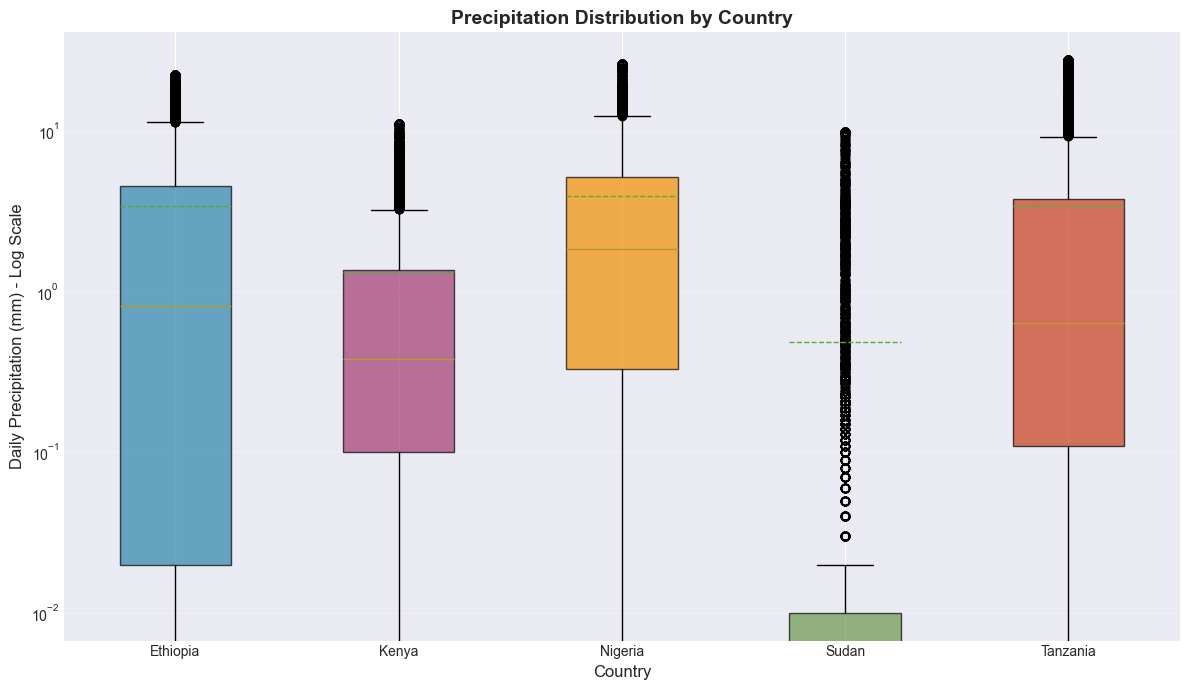

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

countries_list = sorted(combined_df['Country'].unique())
boxplot_data = [combined_df[combined_df['Country'] == country]['PRECTOTCORR'].dropna().values 
                for country in countries_list]

bp = ax.boxplot(boxplot_data, labels=countries_list, patch_artist=True, 
                showmeans=True, meanline=True)

colors_list = [colors.get(c, 'gray') for c in countries_list]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Daily Precipitation (mm)', fontsize=12)
ax.set_title('Precipitation Distribution by Country', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')  # Log scale for better visualization
ax.set_ylabel('Daily Precipitation (mm) - Log Scale', fontsize=12)

plt.tight_layout()
plt.show()

summary statistics of daily percipitation 

In [8]:
precip_stats = combined_df.groupby('Country')['PRECTOTCORR'].agg([
    ('Mean (mm)', 'mean'),
    ('Median (mm)', 'median'),
    ('Std Dev (mm)', 'std'),
    ('Min (mm)', 'min'),
    ('Max (mm)', 'max'),
    ('CV (%)', lambda x: (x.std() / x.mean()) * 100 if x.mean() > 0 else 0)
]).round(2)

precip_stats = precip_stats.sort_values('Mean (mm)', ascending=False)

print("="*60)
print("PRECIPITATION STATISTICS BY COUNTRY")
print("="*60)
precip_stats

PRECIPITATION STATISTICS BY COUNTRY


,Mean (mm),Median (mm),Std Dev (mm),Min (mm),Max (mm),CV (%)
Country,,,,,,
Nigeria,3.95,1.84,5.45,0.00,26.01,138.07
Ethiopia,3.44,0.82,5.37,0.00,22.50,156.21
Tanzania,3.42,0.64,6.00,0.00,27.75,175.46
Kenya,1.32,0.38,2.28,0.00,11.01,172.45
Sudan,0.49,0.00,1.67,0.00,9.82,341.97


Extreme heat days

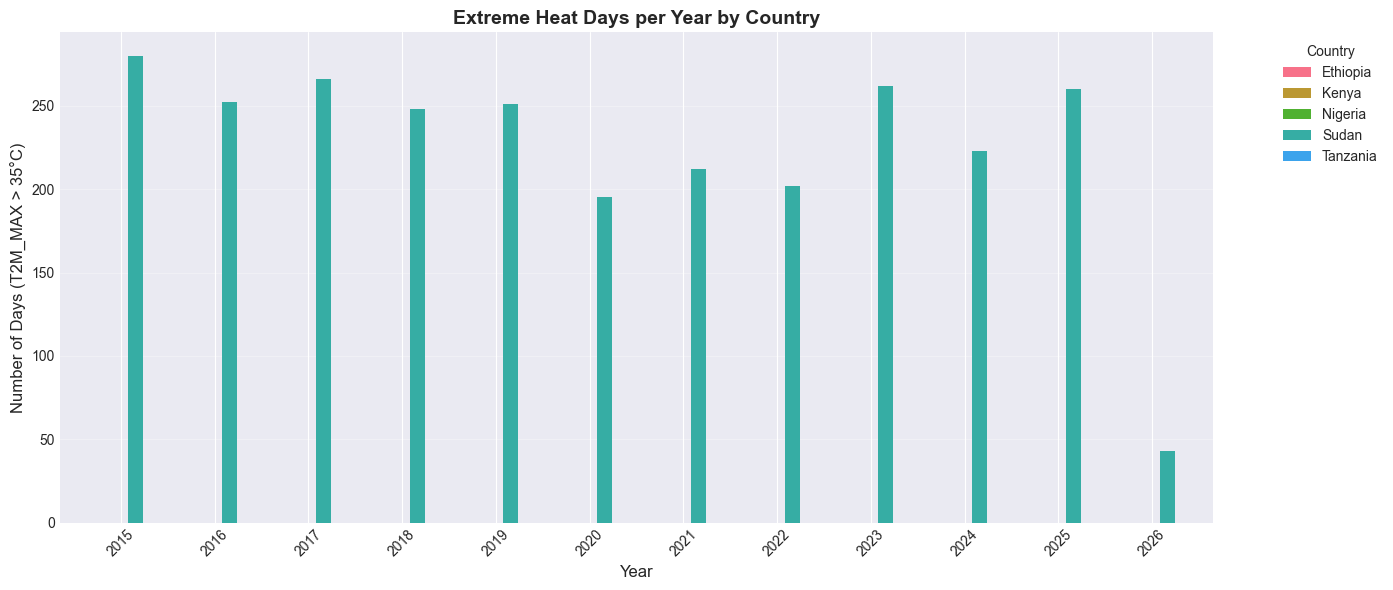


📊 Extreme Heat Days (Average per year):
           mean  max  min   sum
Country                        
Ethiopia   0.00    0    0     0
Kenya      0.00    0    0     0
Nigeria    0.00    0    0     0
Sudan    224.50  280   43  2694
Tanzania   0.00    0    0     0


In [14]:
extreme_heat_list = []

for country in combined_df['Country'].unique():
    country_data = combined_df[combined_df['Country'] == country]
    for year in country_data['YEAR'].unique():
        year_data = country_data[country_data['YEAR'] == year]
        extreme_days = (year_data['T2M_MAX'] > 35).sum()
        extreme_heat_list.append({
            'Country': country,
            'Year': year,
            'Extreme_Heat_Days': extreme_days
        })

extreme_heat = pd.DataFrame(extreme_heat_list)

heat_pivot = extreme_heat.pivot(index='Year', columns='Country', values='Extreme_Heat_Days').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
heat_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Days (T2M_MAX > 35°C)', fontsize=12)
ax.set_title('Extreme Heat Days per Year by Country', fontsize=14, fontweight='bold')
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n📊 Extreme Heat Days (Average per year):")
print(extreme_heat.groupby('Country')['Extreme_Heat_Days'].agg(['mean', 'max', 'min', 'sum']).round(1))

extreme dry weather

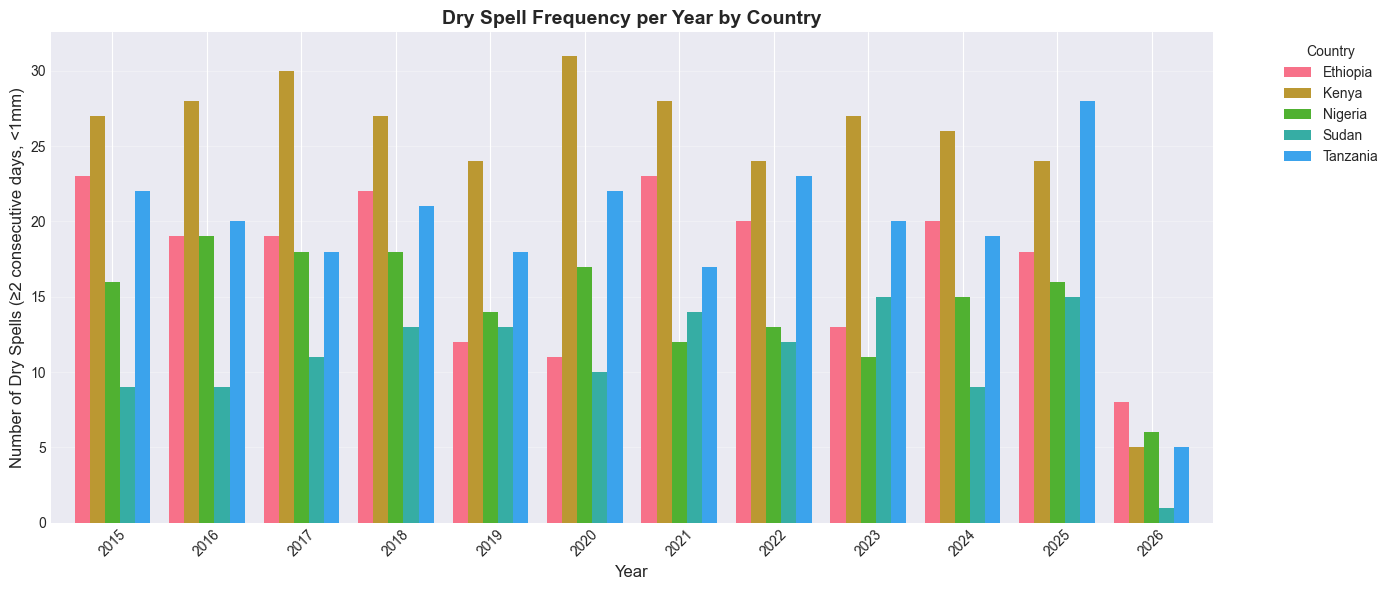


📊 Dry Spells (Average per year):
          mean  max  min  sum
Country                      
Ethiopia 17.30   23    8  208
Kenya    25.10   31    5  301
Nigeria  14.60   19    6  175
Sudan    10.90   15    1  131
Tanzania 19.40   28    5  233


In [16]:
dry_spells_list = []

for country in combined_df['Country'].unique():
    country_data = combined_df[combined_df['Country'] == country]
    for year in country_data['YEAR'].unique():
        year_data = country_data[country_data['YEAR'] == year].sort_values('Date')
        dry_flag = year_data['PRECTOTCORR'] < 1
        dry_streaks = dry_flag.astype(int).groupby((~dry_flag).cumsum()).sum()
        dry_spell_count = (dry_streaks >= 2).sum()
        dry_spells_list.append({
            'Country': country,
            'Year': year,
            'Dry_Spells': dry_spell_count
        })

dry_spells = pd.DataFrame(dry_spells_list)

dry_pivot = dry_spells.pivot(index='Year', columns='Country', values='Dry_Spells').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
dry_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Dry Spells (≥2 consecutive days, <1mm)', fontsize=12)
ax.set_title('Dry Spell Frequency per Year by Country', fontsize=14, fontweight='bold')
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n📊 Dry Spells (Average per year):")
print(dry_spells.groupby('Country')['Dry_Spells'].agg(['mean', 'max', "min", 'sum']).round(1))

statstical testing
    - one way ANOVA & kruskal wallis

In [ ]:
country_groups = [combined_df[combined_df['Country'] == country]['T2M'].dropna().values 
                  for country in combined_df['Country'].unique()]

f_stat, p_value_anova = f_oneway(*country_groups)

h_stat, p_value_kw = kruskal(*country_groups)

print("\n" + "="*60)
print("STATISTICAL TEST RESULTS")
print("="*60)
print(f"One-way ANOVA: F-statistic = {f_stat:.2f}, p-value = {p_value_anova:.6f}")
print(f"Kruskal-Wallis: H-statistic = {h_stat:.2f}, p-value = {p_value_kw:.6f}")
print("="*60)


STATISTICAL TEST RESULTS
One-way ANOVA: F-statistic = 18969.82, p-value = 0.000000
Kruskal-Wallis: H-statistic = 15396.96, p-value = 0.000000


the pvalue of both tests is < 0.05 which indicates that statistically significant differences in temperature exist across countries and the temperature distribution is significantly different from one country to the next.

summary table ranking five countries by climate vulnerability

In [ ]:
vulnerability_data = []

for country in combined_df['Country'].unique():
    country_data = combined_df[combined_df['Country'] == country]
    
    mean_temp = country_data['T2M'].mean()
    
    extreme_heat_yearly = (country_data['T2M_MAX'] > 35).groupby(country_data['YEAR']).sum().mean()
    
    dry_spells_list = []
    for year in country_data['YEAR'].unique():
        year_data = country_data[country_data['YEAR'] == year].sort_values('Date')
        dry_flag = year_data['PRECTOTCORR'] < 1
        dry_streaks = dry_flag.astype(int).groupby((~dry_flag).cumsum()).sum()
        dry_spell_count = (dry_streaks >= 2).sum()
        dry_spells_list.append(dry_spell_count)
    
    dry_spells_yearly = np.mean(dry_spells_list)
    
    mean_precip = country_data['PRECTOTCORR'].mean()
    precip_cv = country_data['PRECTOTCORR'].std() / mean_precip if mean_precip > 0 else 0
    
    vulnerability_data.append({
        'Country': country,
        'Mean Temp (°C)': round(mean_temp, 1),
        'Heat Risk (days/yr)': round(extreme_heat_yearly, 1),
        'Dry Spells (per yr)': round(dry_spells_yearly, 1),
        'Mean Precip (mm)': round(mean_precip, 2),
        'Precip Variability (CV)': round(precip_cv, 2)
    })

vulnerability_df = pd.DataFrame(vulnerability_data)
vulnerability_df

,Country,Mean Temp (°C),Heat Risk (days/yr),Dry Spells (per yr),Mean Precip (mm),Precip Variability (CV)
0,Ethiopia,16.10,0.00,17.30,3.44,1.56
1,Kenya,20.40,0.00,25.10,1.32,1.72
2,Nigeria,26.70,0.00,14.60,3.95,1.38
3,Tanzania,26.80,0.00,19.40,3.42,1.75
4,Sudan,28.80,224.50,10.90,0.49,3.42


- from the above table, we can see that sudan has the highest mean temperature at 28.8°C. this suggests sudan's climate is increasing and warming up fast which increases the country's heat risk days.
- fron the percipitation variability ranking, we can see that sudan again  has a CV of 3.42 which is higher than the others. a high CV means rainfall is highly unstable flactuating between droughts and high rainfall.
- Sudan again has 224.5 heat risk days per year and 10.9 dry spells per year which shows high climate stress. this inturn shows that the country experiences both severe heat exposure and water shortage.  
- from the table, we can see that ethiopia is relatively cooler than the other countries and has no recorded heat risk days. the rainfall variability is also moderate which means precipitation is more stable but still vulnerable.but the table also shows that the country faces 17.3 dry spells annually which means drought is the main challenge rather than heat. 
- based on the above table, sudan should be the priority for climate finance at COP32 since it is the country under the most severe climate stress with  highest mean temperature (28.8°C), extreme heat risk (224.5 days/year) and most unstable rainfall (CV 3.42).